In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('/Users/vedharai/hr-attrition-predictor/data/IBM HR Employee Attrition Data.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

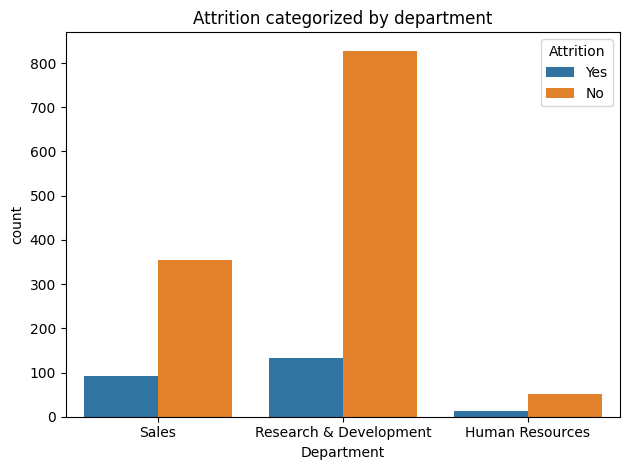

In [14]:
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition categorized by department')
plt.tight_layout()
plt.show()

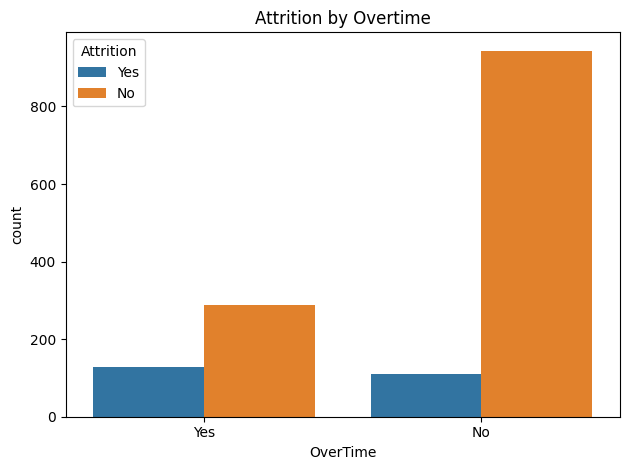

In [13]:
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Attrition by Overtime')
plt.tight_layout()
plt.show()

In [15]:
df.groupby('Attrition')[['Age', 'MonthlyIncome', 'YearsAtCompany', 
                          'DistanceFromHome', 'TotalWorkingYears']].mean().round(1)

,Age,MonthlyIncome,YearsAtCompany,DistanceFromHome,TotalWorkingYears
Attrition,,,,,
No,37.6,6832.7,7.4,8.9,11.9
Yes,33.6,4787.1,5.1,10.6,8.2


Employees who leave generally tend to be younger, newer to the company, paid less, and further away from the location.

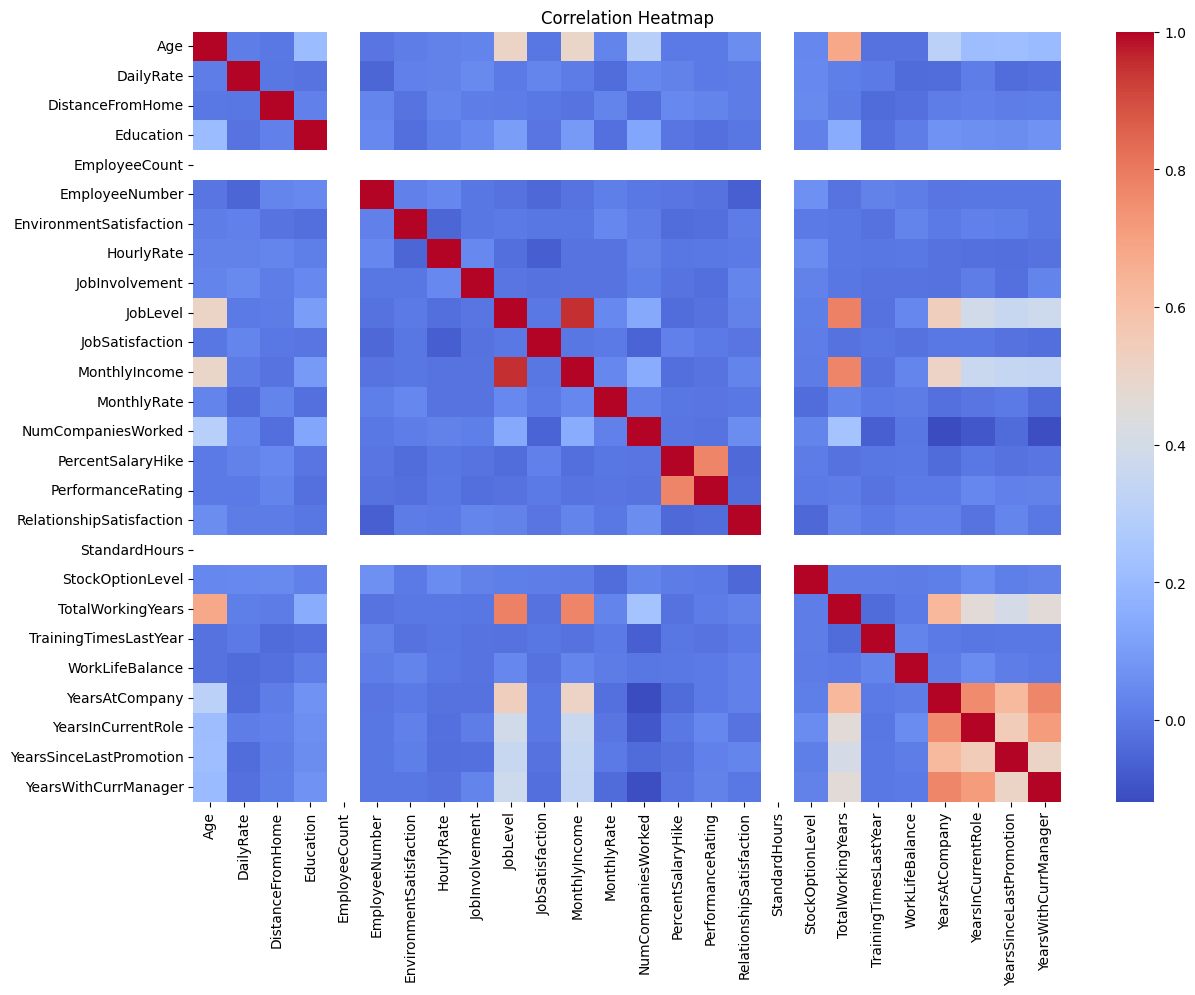

In [16]:
df_numeric = df.select_dtypes(include='number')
plt.figure(figsize=(14,10))
sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [17]:
df.groupby('Attrition')[['JobSatisfaction', 'WorkLifeBalance', 
                          'EnvironmentSatisfaction']].mean().round(2)

,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction
Attrition,,,
No,2.78,2.78,2.77
Yes,2.47,2.66,2.46


In addition to being younger and less paid, they also report lower job and environment satisfaction on average.

## EDA Summary:

1. Employees who left were younger (avg 33.6 vs 37.6)
2. They earned significantly less (avg ₹4787/month vs ₹6832/month)
3. They worked fewer years at the company (5.1 vs 7.4)
4. Overtime workers leave at a much higher rate (could possibly be affecting job satisfaction).
5. Lower job and environment satisfaction among those who left

Thus, attrition is still driven primarily by low salary, younger age, and working overtime, not only job satisfaction alone.